---
format:
  html:
    page-layout: full
    toc: true
    toc-location: left
    code-fold: true
    code-summary: "Show Code"
    theme: cosmo
---

# Week 5B: Raster Data Analysis

## Comparing Walker Lake in 1988 and 2017

**Question:** How did the lake's visible extent and surrounding land cover change?

In this lab, you will:

1. Download and read a small set of Landsat bands.
2. Display natural-color (RGB) images and select a shared study area.
3. Calculate the Normalized Difference Vegetation Index (NDVI).
4. Align the rasters to a common grid and map NDVI change.
5. Explore how a coarser resolution changes the map.

Run the cells **from top to bottom**. Use the course Python environment and start Jupyter in `week-5-raster-analysis` so that relative paths work. The first download requires an internet connection; later runs reuse the downloaded files.

## 1. Study area and setup

Walker Lake is a saline lake in Nevada. These NASA images provide context for the comparison:

**1988**

<img src="imgs/walker-1.jpeg" width="600" alt="Walker Lake in 1988">

**2017**

<img src="imgs/walker-2.jpeg" width="600" alt="Walker Lake in 2017">

Source: [NASA Earth Observatory: Disappearing Walker Lake](https://science.nasa.gov/earth/earth-observatory/disappearing-walker-lake-91921/).

**Before coding:** Where do you see the largest shoreline changes? We will compare these observations with the raster results. This lab examines surface change; estimating water volume would also require water-level and lake-depth information.

### Import the libraries

- `requests` downloads files; `Path` manages their locations.
- `rioxarray` reads GeoTIFFs with spatial metadata; `xarray` organizes bands and coordinates.
- `numpy` creates the comparison grid.
- `matplotlib` and `earthpy` display RGB images; `hvplot` provides interactive raster maps.

The small teaching subsets fit in memory. We read them with ordinary NumPy-backed arrays. If an import fails, select the course environment before continuing.

In [1]:
from pathlib import Path

import requests
import numpy as np
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import earthpy.plot as ep
import hvplot.xarray

## 2. Download only the bands we need

We use two small, preprocessed surface-reflectance subsets hosted on Amazon S3. They have already been cropped and resampled for teaching; their pixel sizes differ from each other and from native Landsat imagery.

| Image | Acquisition date | RGB bands (red, green, blue) | Near infrared (NIR) |
| --- | --- | --- | --- |
| Landsat 5 | October 22, 1988 | 3, 2, 1 | 4 |
| Landsat 8 | October 22, 2017 | 4, 3, 2 | 5 |

Only four bands per date are needed. We will keep each band as a separate GeoTIFF and combine them in memory, so there is no intermediate stacked file to create.

In [2]:
base_url = "https://earth-data.s3.amazonaws.com/landsat/small"
data_dir = Path("data/walker_lake")

scene_1988 = "LT05_L1TP_042033_19881022_20161001_01_T1"
scene_2017 = "LC08_L1TP_042033_20171022_20171107_01_T1"

bands_1988 = [1, 2, 3, 4]
bands_2017 = [2, 3, 4, 5]

### Download the Landsat 5 bands (1988)

We download one band at a time using a `for` loop. `files_1988` stores the file paths in the same order as `bands_1988`. Existing files are reused. `raise_for_status()` stops the cell if a download fails, so a missing band is not silently skipped.

In [3]:
folder_1988 = data_dir / scene_1988
folder_1988.mkdir(parents=True, exist_ok=True)
files_1988 = []

for band in bands_1988:
    filename = f"{scene_1988}_sr_band{band}.tif"
    path = folder_1988 / filename

    if not path.exists():
        print(f"Downloading 1988 band {band}")
        response = requests.get(f"{base_url}/{filename}", timeout=60)
        response.raise_for_status()
        path.write_bytes(response.content)
    
    files_1988.append(path)

print("1988 files:", files_1988)

1988 files: [PosixPath('data/walker_lake/LT05_L1TP_042033_19881022_20161001_01_T1/LT05_L1TP_042033_19881022_20161001_01_T1_sr_band1.tif'), PosixPath('data/walker_lake/LT05_L1TP_042033_19881022_20161001_01_T1/LT05_L1TP_042033_19881022_20161001_01_T1_sr_band2.tif'), PosixPath('data/walker_lake/LT05_L1TP_042033_19881022_20161001_01_T1/LT05_L1TP_042033_19881022_20161001_01_T1_sr_band3.tif'), PosixPath('data/walker_lake/LT05_L1TP_042033_19881022_20161001_01_T1/LT05_L1TP_042033_19881022_20161001_01_T1_sr_band4.tif')]


### Download the Landsat 8 bands (2017)

Repeat the same steps for 2017. Notice that this image uses bands 2–5, while the 1988 image uses bands 1–4.

In [4]:
folder_2017 = data_dir / scene_2017
folder_2017.mkdir(parents=True, exist_ok=True)
files_2017 = []

for band in bands_2017:
    filename = f"{scene_2017}_sr_band{band}.tif"
    path = folder_2017 / filename

    if not path.exists():
        print(f"Downloading 2017 band {band}")
        response = requests.get(f"{base_url}/{filename}", timeout=60)
        response.raise_for_status()
        path.write_bytes(response.content)

    files_2017.append(path)

print("2017 files:", files_2017)

2017 files: [PosixPath('data/walker_lake/LC08_L1TP_042033_20171022_20171107_01_T1/LC08_L1TP_042033_20171022_20171107_01_T1_sr_band2.tif'), PosixPath('data/walker_lake/LC08_L1TP_042033_20171022_20171107_01_T1/LC08_L1TP_042033_20171022_20171107_01_T1_sr_band3.tif'), PosixPath('data/walker_lake/LC08_L1TP_042033_20171022_20171107_01_T1/LC08_L1TP_042033_20171022_20171107_01_T1_sr_band4.tif'), PosixPath('data/walker_lake/LC08_L1TP_042033_20171022_20171107_01_T1/LC08_L1TP_042033_20171022_20171107_01_T1_sr_band5.tif')]


## 3. Read and inspect the rasters

Each GeoTIFF contains one band. For each year, we read the files into a list and then combine them into a `DataArray` with dimensions `(band, y, x)`.

- `masked=True` converts declared no-data values to `NaN` (missing values).
- `.load()` reads each small array into memory; `.close()` then closes its file.
- `xr.concat(..., dim="band")` stacks the arrays along the band dimension.
- `.assign_coords(band=...)` labels the bands with their original Landsat numbers.
- `join="exact"` checks that the bands within each scene share the same x/y grid.

Reference: [rioxarray's raster reader](https://corteva.github.io/rioxarray/html/rioxarray.html#rioxarray.open_rasterio).

### Read the 1988 bands

In [5]:
arrays_1988 = []

for path in files_1988:
    raster = rxr.open_rasterio(path, masked=True)
    raster.load()
    raster.close()
    arrays_1988.append(raster)

landsat_1988 = xr.concat(arrays_1988, dim="band", join="exact")
landsat_1988 = landsat_1988.assign_coords(band=bands_1988)
landsat_1988

<xarray.DataArray (band: 4, y: 300, x: 300)> Size: 3MB
array([[[ 640.,  842.,  864., ..., 1250.,  929., 1111.],
        [ 796.,  774.,  707., ..., 1136.,  906., 1065.],
        [ 975.,  707.,  908., ..., 1386., 1249., 1088.],
        ...,
        [1243., 1202., 1160., ..., 1132., 1067.,  845.],
        [1287., 1334., 1292., ...,  801.,  934.,  845.],
        [1550., 1356., 1314., ..., 1309., 1636., 1199.]],

       [[ 810., 1096., 1191., ..., 1749., 1266., 1411.],
        [1096., 1048.,  905., ..., 1556., 1217., 1411.],
        [1286., 1000., 1286., ..., 1749., 1604., 1411.],
        ...,
        [1752., 1565., 1566., ..., 1502., 1456., 1078.],
        [1752., 1799., 1706., ...,  983., 1172., 1077.],
        [1893., 1753., 1754., ..., 1736., 2250., 1736.]],

       [[1007., 1345., 1471., ..., 2102., 1462., 1719.],
        [1260., 1259., 1175., ..., 1847., 1419., 1719.],
        [1555., 1175., 1555., ..., 2059., 1889., 1760.],
        ...,
        [2090., 1840., 1798., ..., 1828., 1703., 1242.],
        [2048., 2049., 2008., ..., 1074., 1326., 1158.],
        [2216., 1965., 2049., ..., 2202., 2783., 1994.]],

       [[1221., 1662., 1809., ..., 2401., 1660., 1957.],
        [1564., 1465., 1367., ..., 2105., 1610., 1907.],
        [2004., 1465., 1955., ..., 2302., 2055., 2006.],
        ...,
        [2429., 2138., 2041., ..., 2175., 1885., 1301.],
        [2381., 2333., 2382., ..., 1204., 1495., 1301.],
        [2478., 2041., 2333., ..., 2755., 3431., 2223.]]],
      shape=(4, 300, 300))
Coordinates:
  * x            (x) float64 2kB 3.324e+05 3.326e+05 ... 3.771e+05 3.772e+05
  * y            (y) float64 2kB 4.309e+06 4.309e+06 ... 4.264e+06 4.264e+06
    spatial_ref  int64 8B 0
  * band         (band) int64 32B 1 2 3 4
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

### Read the 2017 bands

In [6]:
arrays_2017 = []

for path in files_2017:
    raster = rxr.open_rasterio(path, masked=True)
    raster.load()
    raster.close()
    arrays_2017.append(raster)

landsat_2017 = xr.concat(arrays_2017, dim="band", join="exact")
landsat_2017 = landsat_2017.assign_coords(band=bands_2017)
landsat_2017

<xarray.DataArray (band: 4, y: 286, x: 286)> Size: 3MB
array([[[ 739.,  722.,  708., ..., 1305., 1398., 1574.],
        [1174.,  797.,  638., ..., 1298., 1757., 1511.],
        [ 859.,  810., 1059., ..., 1596., 1808., 1444.],
        ...,
        [ 867.,  800.,  658., ...,  723.,  820.,  631.],
        [ 868.,  731.,  915., ...,  910., 1166., 1155.],
        [ 664.,  762.,  755., ...,  729.,  690., 1071.]],

       [[1066.,  875.,  893., ..., 1776., 1928., 2151.],
        [1645.,  939.,  857., ..., 1801., 2539., 2023.],
        [1166., 1107., 1437., ..., 2188., 2409., 1925.],
        ...,
        [1182., 1106.,  877., ...,  918., 1086.,  807.],
        [1207.,  986., 1296., ..., 1142., 1606., 1587.],
        [ 883., 1024., 1020., ...,  923.,  884., 1401.]],

       [[1106., 1064., 1101., ..., 2153., 2304., 2541.],
        [2221., 1179., 1072., ..., 2162., 3084., 2381.],
        [1396., 1274., 1747., ..., 2529., 2829., 2317.],
        ...,
        [1543., 1462., 1121., ..., 1094., 1312.,  993.],
        [1595., 1270., 1748., ..., 1337., 1983., 1965.],
        [1186., 1369., 1347., ..., 1108., 1055., 1714.]],

       [[3310., 1453., 1495., ..., 2675., 2820., 3011.],
        [3419., 1633., 1498., ..., 2601., 3571., 2867.],
        [2748., 3202., 2466., ..., 3006., 3264., 2822.],
        ...,
        [2184., 2067., 1755., ..., 1493., 1705., 1282.],
        [2172., 1736., 2367., ..., 1716., 2368., 2346.],
        [1711., 1930., 1919., ..., 1501., 1356., 2020.]]],
      shape=(4, 286, 286))
Coordinates:
  * x            (x) float64 2kB 3.183e+05 3.185e+05 ... 3.779e+05 3.782e+05
  * y            (y) float64 2kB 4.321e+06 4.321e+06 ... 4.261e+06 4.261e+06
    spatial_ref  int64 8B 0
  * band         (band) int64 32B 2 3 4 5
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

### Compare the raster metadata

In [7]:
print("1988 dimensions:", landsat_1988.dims)
print("1988 shape:", landsat_1988.shape)
print("1988 bands:", landsat_1988.band.values)
print("1988 CRS:", landsat_1988.rio.crs)
print("1988 pixel size:", landsat_1988.rio.resolution())
print("1988 bounds:", landsat_1988.rio.bounds())

1988 dimensions: ('band', 'y', 'x')
1988 shape: (4, 300, 300)
1988 bands: [1 2 3 4]
1988 CRS: EPSG:32611
1988 pixel size: (150.0, -150.0)
1988 bounds: (332325.0, 4264275.0, 377325.0, 4309275.0)


In [8]:
print("2017 dimensions:", landsat_2017.dims)
print("2017 shape:", landsat_2017.shape)
print("2017 bands:", landsat_2017.band.values)
print("2017 CRS:", landsat_2017.rio.crs)
print("2017 pixel size:", landsat_2017.rio.resolution())
print("2017 bounds:", landsat_2017.rio.bounds())

2017 dimensions: ('band', 'y', 'x')
2017 shape: (4, 286, 286)
2017 bands: [2 3 4 5]
2017 CRS: EPSG:32611
2017 pixel size: (210.0, -210.0)
2017 bounds: (318195.0, 4260945.0, 378255.0, 4321005.0)


In [9]:
# Both images must use the same CRS before we compare their coordinates.
assert landsat_1988.rio.crs == landsat_2017.rio.crs, "Reproject before comparing different CRSs."

**Check your output:** These files use EPSG:32611 (UTM zone 11N), with coordinates in meters. This is the CRS of these particular files, not a universal Landsat CRS. The subset pixel sizes are 150 m for 1988 and 210 m for 2017. A negative y resolution means rows run from north to south.

The array shape tells you how many bands, rows, and columns there are. Equal shapes alone would not prove that two rasters cover the same locations.

## 4. Display natural-color images

`.sel(band=[...])` selects bands by their **labels**. `.values` exposes the data as a NumPy array for EarthPy. After selection, `rgb=(0, 1, 2)` means the first, second, and third positions in that selected array.

Each image is stretched separately to make features visible. Compare the shoreline and land features, rather than treating the displayed brightness as a quantitative comparison.

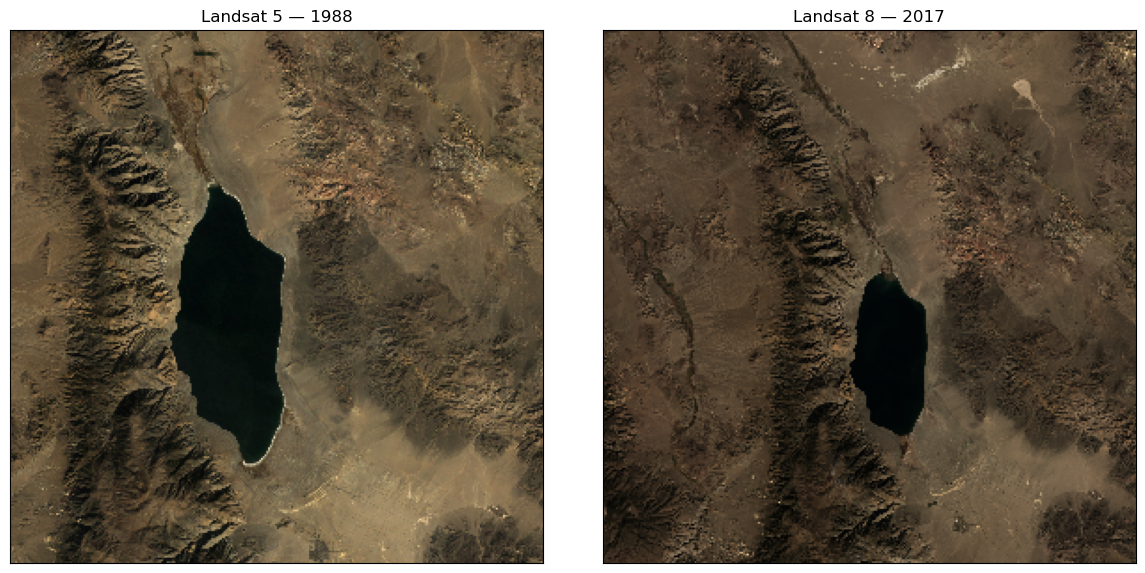

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ep.plot_rgb(landsat_1988.sel(band=[3, 2, 1]).values,
            rgb=(0, 1, 2), ax=axes[0], title="Landsat 5 — 1988")
ep.plot_rgb(landsat_2017.sel(band=[4, 3, 2]).values,
            rgb=(0, 1, 2), ax=axes[1], title="Landsat 8 — 2017")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## 5. Select the shared study area

The original images cover different extents. We use the overlap of their x and y coordinate ranges so that both images contain data for our study area. Coordinates represent **pixel centers**.

For an overlap, the lower bound is the larger of the two minimum values, and the upper bound is the smaller of the two maximum values.

In [11]:
xmin = max(landsat_1988.x.min().item(), landsat_2017.x.min().item())
xmax = min(landsat_1988.x.max().item(), landsat_2017.x.max().item())
ymin = max(landsat_1988.y.min().item(), landsat_2017.y.min().item())
ymax = min(landsat_1988.y.max().item(), landsat_2017.y.max().item())
assert xmin < xmax and ymin < ymax, "The images do not overlap."

print(f"Shared x range: {xmin:.0f} to {xmax:.0f} m")
print(f"Shared y range: {ymin:.0f} to {ymax:.0f} m")

Shared x range: 332400 to 377250 m
Shared y range: 4264350 to 4309200 m


### Slice by coordinate values

`slice(start, stop)` selects a coordinate interval when used with `.sel()`. The x coordinates increase, but y coordinates decrease, so the y slice must go from `ymax` to `ymin`.

Cropping makes the extents similar. It does **not** make pixel centers or resolutions identical.

In [12]:
slice_x = slice(xmin, xmax)
slice_y = slice(ymax, ymin)

crop_1988 = landsat_1988.sel(x=slice_x, y=slice_y)
crop_2017 = landsat_2017.sel(x=slice_x, y=slice_y)

print("1988 cropped shape:", crop_1988.shape)
print("2017 cropped shape:", crop_2017.shape)

1988 cropped shape: (4, 300, 300)
2017 cropped shape: (4, 214, 213)


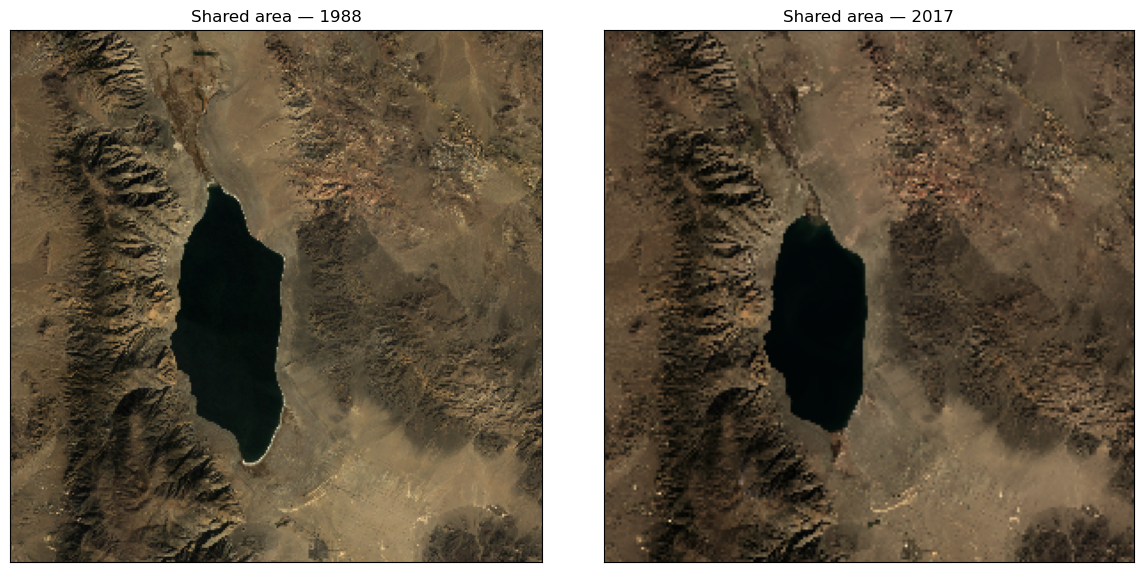

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ep.plot_rgb(crop_1988.sel(band=[3, 2, 1]).values,
            rgb=(0, 1, 2), ax=axes[0], title="Shared area — 1988")
ep.plot_rgb(crop_2017.sel(band=[4, 3, 2]).values,
            rgb=(0, 1, 2), ax=axes[1], title="Shared area — 2017")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

**Checkpoint:** Identify an area that appears to have changed from water to exposed land. Why did we crop before comparing the images visually?

## 6. Calculate NDVI

The Normalized Difference Vegetation Index compares near-infrared and red reflectance:

$$\mathrm{NDVI} = \frac{\mathrm{NIR} - \mathrm{Red}}{\mathrm{NIR} + \mathrm{Red}}$$

Vegetation generally has higher NDVI; water often has low or negative NDVI. NDVI is not a water classification or a measurement of water depth.

For Landsat 5, use NIR band **4** and red band **3**. For Landsat 8, use NIR band **5** and red band **4**. See [USGS: Landsat NDVI](https://www.usgs.gov/landsat-missions/landsat-normalized-difference-vegetation-index).

These preprocessed surface-reflectance bands use a common multiplicative scale, which cancels in the ratio. For other products, check the scale and offset before calculating NDVI.

We calculate NDVI on each full subset first, keeping edge pixels available for interpolation. We mask zero denominators explicitly rather than suppressing numerical warnings.

### NDVI for 1988

Select the NIR and red bands, add them to get the denominator, then apply the formula. `drop=True` removes the single band label after selection. `.where(denominator_1988 != 0)` replaces zero denominators with missing values.

In [14]:
nir_1988 = landsat_1988.sel(band=4, drop=True)
red_1988 = landsat_1988.sel(band=3, drop=True)

denominator_1988 = nir_1988 + red_1988
denominator_1988 = denominator_1988.where(denominator_1988 != 0)
ndvi_1988 = (nir_1988 - red_1988) / denominator_1988
ndvi_1988 = ndvi_1988.rename("NDVI")

### NDVI for 2017

Use the same formula with the Landsat 8 band numbers: NIR is band 5 and red is band 4.

In [15]:
nir_2017 = landsat_2017.sel(band=5, drop=True)
red_2017 = landsat_2017.sel(band=4, drop=True)

denominator_2017 = nir_2017 + red_2017
denominator_2017 = denominator_2017.where(denominator_2017 != 0)
ndvi_2017 = (nir_2017 - red_2017) / denominator_2017
ndvi_2017 = ndvi_2017.rename("NDVI")

## 7. Put both dates on the same grid

### Why not subtract immediately?

Xarray normally aligns arithmetic using the **intersection of matching coordinate labels**. It does not automatically resample rasters. With different pixel centers, direct subtraction may keep very few coordinates or produce an empty result.

Inspect the starting coordinates and spacing before calculating a difference. Reference: [xarray's automatic alignment](https://docs.xarray.dev/en/stable/user-guide/computation.html#automatic-alignment).

In [16]:
print("1988 first x:", ndvi_1988.x[0].item())
print("2017 first x:", ndvi_2017.x[0].item())
print("1988 first y:", ndvi_1988.y[0].item())
print("2017 first y:", ndvi_2017.y[0].item())

1988 first x: 332400.0
2017 first x: 318300.0
1988 first y: 4309200.0
2017 first y: 4320900.0


In [17]:
spacing_1988 = abs(ndvi_1988.x[1].item() - ndvi_1988.x[0].item())
spacing_2017 = abs(ndvi_2017.x[1].item() - ndvi_2017.x[0].item())
print("1988 x spacing (m):", spacing_1988)
print("2017 x spacing (m):", spacing_2017)

1988 x spacing (m): 150.0
2017 x spacing (m): 210.0


### Create a shared 200 m grid

Both rasters already have the same projected CRS, so we can interpolate using x and y coordinates. We use a 200 m grid inside the overlap for this exercise. Interpolation estimates values at new pixel centers; it does not create additional observed detail or perform a CRS transformation.

We keep y descending, as in the source rasters. `np.arange()` excludes its stop value.

In [18]:
resolution = 200  # meters between target pixel centers
x = np.arange(xmin, xmax, resolution)
y = np.arange(ymax, ymin, -resolution)

ndvi_1988_aligned = ndvi_1988.interp(x=x, y=y, method="linear")
ndvi_2017_aligned = ndvi_2017.interp(x=x, y=y, method="linear")

print("Aligned shapes:", ndvi_1988_aligned.shape, ndvi_2017_aligned.shape)
assert ndvi_1988_aligned.x.equals(ndvi_2017_aligned.x)
assert ndvi_1988_aligned.y.equals(ndvi_2017_aligned.y)

Aligned shapes: (225, 225) (225, 225)


### Compare NDVI with the same color scale

The maps below use projected x/y coordinates in meters. Hover to inspect values, and use the toolbar to pan or zoom. Both dates use the same color limits so the colors are comparable.

In [19]:
map_1988 = ndvi_1988_aligned.hvplot.image(
    x="x", y="y",
    data_aspect=1, width=450, height=450,
    colorbar=True, xlabel="Easting (m)", ylabel="Northing (m)",
    cmap="RdYlGn", clim=(-1, 1), title="NDVI — 1988"
)
map_2017 = ndvi_2017_aligned.hvplot.image(
    x="x", y="y",
    data_aspect=1, width=450, height=450,
    colorbar=True, xlabel="Easting (m)", ylabel="Northing (m)",
    cmap="RdYlGn", clim=(-1, 1), title="NDVI — 2017"
)
map_1988 + map_2017

:Layout
   .Image.I  :Image   [x,y]   (NDVI)
   .Image.II :Image   [x,y]   (NDVI)

## 8. Map and interpret NDVI change

Subtract **1988 from 2017**:

- Positive (red): NDVI increased.
- Negative (blue): NDVI decreased.
- Near zero: little change in NDVI.

The difference can theoretically range from −2 to 2 when both NDVI values are in [−1, 1]. We display the full range with a diverging color scale centered on zero.

In [20]:
ndvi_change = (ndvi_2017_aligned - ndvi_1988_aligned).rename("NDVI change")

ndvi_change.hvplot.image(
    x="x", y="y",
    data_aspect=1, width=450, height=450,
    colorbar=True, xlabel="Easting (m)", ylabel="Northing (m)",
    cmap="coolwarm", clim=(-2, 2),
    title="NDVI change: 2017 minus 1988"
)

:Image   [x,y]   (NDVI change)

### What can we conclude?

Compare the change map with the RGB images. Higher NDVI near a former shoreline may be consistent with exposed land or new vegetation. A red pixel alone does not establish that water disappeared: vegetation conditions, sensor differences, clouds, and other factors can also affect NDVI.

This is an exploratory comparison of two prepared scenes. A quantitative lake-area study would need a validated water mask and quality screening; a lake-volume estimate would also need depth or water-level information.

**Discuss:** Which changes match the visible shoreline retreat? Which changes occur away from the lake?

## 9. Explore a coarser resolution

We can summarize the 200 m grid into 1,000 m cells by averaging each **5 × 5 block**. Xarray's `.coarsen()` is a direct way to do this on a regular grid.

`boundary="trim"` drops incomplete blocks along the edges. `.mean(skipna=True)` averages available values; a block with no valid values remains missing. This aggregation smooths local variation, whereas the earlier interpolation estimated values at new coordinates.

In [21]:
ndvi_change_1000 = ndvi_change.coarsen(x=5, y=5, boundary="trim").mean(skipna=True)

print("200 m grid:", ndvi_change.shape)
print("1,000 m grid:", ndvi_change_1000.shape)

fine_map = ndvi_change.hvplot.image(
    x="x", y="y",
    data_aspect=1, width=450, height=450,
    colorbar=True, xlabel="Easting (m)", ylabel="Northing (m)",
    cmap="coolwarm", clim=(-2, 2), title="NDVI change — 200 m"
)
coarse_map = ndvi_change_1000.hvplot.image(
    x="x", y="y",
    data_aspect=1, width=450, height=450,
    colorbar=True, xlabel="Easting (m)", ylabel="Northing (m)",
    cmap="coolwarm", clim=(-2, 2), title="NDVI change — 1,000 m"
)
fine_map + coarse_map

200 m grid: (225, 225)
1,000 m grid: (45, 45)


:Layout
   .Image.I  :Image   [x,y]   (NDVI change)
   .Image.II :Image   [x,y]   (NDVI change)

## 10. Check your understanding

1. Why do Landsat 5 and Landsat 8 use different band numbers for RGB and NDVI?
2. What is the difference between cropping to a shared area and aligning pixel grids?
3. What does a positive value in `ndvi_change` mean? Why is it not a direct measure of lost lake volume?
4. Which shoreline details become harder to see on the 1,000 m map?

**Practice:** Change the coarsening window to 10 × 10. Calculate the new resolution in meters, then describe one advantage and one disadvantage of that map.